### Самый честный способ создания диффузионной задачи

In [1]:
from yggdrasill import Hypergraph
from yggdrasill.engine.edge import Edge
from yggdrasill.integrations.diffusers import contracts as C
from yggdrasill.integrations.diffusers.model_store import ModelStore

store = ModelStore.default()
repo = "runwayml/stable-diffusion-v1-5"
components = store.load_components_by_keys(
    "sd15", ["tokenizer", "text_encoder", "unet", "vae", "scheduler"],
    repo, variant="fp16", torch_dtype="float16",
)

graph = Hypergraph(name="MySD15Graph")
cfg = {"height": 512, "width": 512, "num_inference_steps": 50, "device": "cuda", "guidance_scale": 7.5}

graph.add_node("tokenizer", type="sd15/tokenizer", config={"tokenizer": components["tokenizer"]})
graph.add_node("prompt_enc", type="sd15/prompt_encoder", config={
    "text_encoder": components["text_encoder"],
})
graph.add_node("sched_setup", type="sd15/scheduler_setup", config={
    "scheduler": components["scheduler"],
    "num_inference_steps": cfg["num_inference_steps"],
    "device": cfg["device"],
})
graph.add_node("latent_init", type="sd15/latent_init", config={
        "height": cfg["height"], "width": cfg["width"],
        "device": cfg["device"], "dtype": "float16",
})
graph.add_node("unet", type="sd15/unet", config={
    "unet": components["unet"],
    "guidance_scale": cfg["guidance_scale"],
})
graph.add_node("sched_step", type="sd15/scheduler_step", config={"scheduler": components["scheduler"]})
graph.add_node("vae_decode", type="sd15/vae_decode", config={
    "vae": components["vae"],
    "output_type": "pil",
})

# Edges
graph.add_edge(Edge("tokenizer", C.PORT_INPUT_IDS, "prompt_enc", C.PORT_INPUT_IDS))
graph.add_edge(Edge("tokenizer", C.PORT_NEGATIVE_INPUT_IDS, "prompt_enc", C.PORT_NEGATIVE_INPUT_IDS))
graph.add_edge(Edge("sched_setup", C.PORT_SCHEDULER_STATE, "latent_init", C.PORT_SCHEDULER_STATE))
graph.add_edge(Edge("sched_setup", C.PORT_SCHEDULER_STATE, "unet", C.PORT_SCHEDULER_STATE))
graph.add_edge(Edge("prompt_enc", C.PORT_PROMPT_EMBEDS, "unet", C.PORT_PROMPT_EMBEDS))
graph.add_edge(Edge("prompt_enc", C.PORT_NEGATIVE_PROMPT_EMBEDS, "unet", C.PORT_NEGATIVE_PROMPT_EMBEDS))
graph.add_edge(Edge("latent_init", C.PORT_LATENTS, "unet", C.PORT_LATENTS))
graph.add_edge(Edge("latent_init", C.PORT_LATENTS, "sched_step", C.PORT_LATENTS))
graph.add_edge(Edge("latent_init", C.PORT_TIMESTEP, "unet", C.PORT_TIMESTEP))
graph.add_edge(Edge("latent_init", C.PORT_TIMESTEP, "sched_step", C.PORT_TIMESTEP))
graph.add_edge(Edge("unet", C.PORT_NOISE_PRED, "sched_step", C.PORT_NOISE_PRED))
graph.add_edge(Edge("sched_step", "next_latent", "unet", C.PORT_LATENTS))
graph.add_edge(Edge("sched_step", "next_latent", "sched_step", C.PORT_LATENTS))
graph.add_edge(Edge("sched_step", "next_timestep", "unet", C.PORT_TIMESTEP))
graph.add_edge(Edge("sched_step", "next_timestep", "sched_step", C.PORT_TIMESTEP))
graph.add_edge(Edge("sched_step", "next_latent", "vae_decode", C.PORT_LATENTS))

graph.expose_input("tokenizer", C.PORT_PROMPT, C.PORT_PROMPT)
graph.expose_input("tokenizer", C.PORT_NEGATIVE_PROMPT, C.PORT_NEGATIVE_PROMPT)
graph.expose_output("vae_decode", C.PORT_DECODED_IMAGE, C.PORT_OUTPUT_IMAGE)
graph.metadata["num_loop_steps"] = cfg["num_inference_steps"]

graph.to("cuda")

/workspace/YggDrasill/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[yggdrasill] Loading components from runwayml/stable-diffusion-v1-5: tokenizer, text_encoder, unet, vae, scheduler
[yggdrasill] Loading CLIPTokenizer from runwayml/stable-diffusion-v1-5/tokenizer ...
[yggdrasill] Loaded CLIPTokenizer from runwayml/stable-diffusion-v1-5/tokenizer
[yggdrasill] Loading CLIPTextModel from runwayml/stable-diffusion-v1-5/text_encoder ...
[yggdrasill] Loaded CLIPTextModel from runwayml/stable-diffusion-v1-5/text_encoder
[yggdrasill] Loading UNet2DConditionModel from runwayml/stable-diffusion-v1-5/unet ...
Passed `torch_dtype` torch.float32 is not a `torch.dtype`. Defaulting to `torch.float32`.
/workspace/YggDrasill/.venv/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:206: UserWarning

Generating: 100%|██████████| 51/51 [00:06<00:00,  8.19step/s]


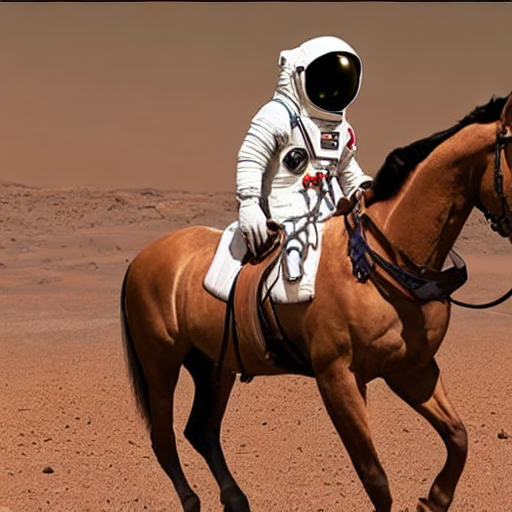

In [2]:
output = graph.run(
    prompt="A photo of an astronaut riding a horse on mars",
    negative_prompt="blurry",
    num_inference_steps=50,
    guidance_scale=7.5,
    num_images_per_prompt=1,
    seed=42,
    width=512,
    height=512,
)

output.images[0]

### Созданиче через специализированный DiffusionGraphBuilder

In [3]:
from yggdrasill import DiffusionGraphBuilder

repo = "runwayml/stable-diffusion-v1-5"

builder = DiffusionGraphBuilder(name="MySD15Graph")
builder.add_component("Backbone", "sd15.unet", pretrained=repo)
builder.add_component("Scheduler", "sd15.scheduler", pretrained=repo)
builder.add_component("Tokenizer", "sd15.tokenizer", pretrained=repo)
builder.add_component("TextEncoder", "sd15.text_encoder", pretrained=repo)
builder.add_component("Autoencoder", "sd15.vae", pretrained=repo)
builder.to("cuda")

[yggdrasill] Loading components from runwayml/stable-diffusion-v1-5: unet
[yggdrasill] Component cache hit: UNet2DConditionModel from runwayml/stable-diffusion-v1-5/unet
[yggdrasill] Loaded 1/1 components: unet
[yggdrasill] Loading components from runwayml/stable-diffusion-v1-5: scheduler
[yggdrasill] Component cache hit: Scheduler from runwayml/stable-diffusion-v1-5/scheduler
[yggdrasill] Loaded 1/1 components: scheduler
[yggdrasill] Loading components from runwayml/stable-diffusion-v1-5: tokenizer
[yggdrasill] Component cache hit: CLIPTokenizer from runwayml/stable-diffusion-v1-5/tokenizer
[yggdrasill] Loaded 1/1 components: tokenizer
[yggdrasill] Loading components from runwayml/stable-diffusion-v1-5: text_encoder
[yggdrasill] Component cache hit: CLIPTextModel from runwayml/stable-diffusion-v1-5/text_encoder
[yggdrasill] Loaded 1/1 components: text_encoder
[yggdrasill] Loading components from runwayml/stable-diffusion-v1-5: vae
[yggdrasill] Component cache hit: AutoencoderKL from r

Generating: 100%|██████████| 51/51 [00:06<00:00,  8.48step/s]


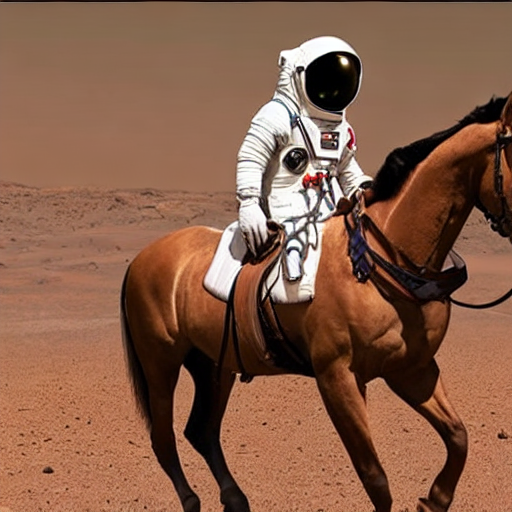

In [4]:
output = builder.run(
    prompt="A photo of an astronaut riding a horse on mars",
    negative_prompt="blurry",
    num_inference_steps=50,
    guidance_scale=7.5,
    num_images_per_prompt=1,
    seed=42,
    width=512,
    height=512,
)

output.images[0]

### Использование в 2 строчки кода

In [5]:
from yggdrasill import Hypergraph

graph = Hypergraph.from_template("sd15_text2image", device="cuda")

[yggdrasill] Loading components from runwayml/stable-diffusion-v1-5: tokenizer, text_encoder, unet, vae, scheduler
[yggdrasill] Component cache hit: CLIPTokenizer from runwayml/stable-diffusion-v1-5/tokenizer
[yggdrasill] Component cache hit: CLIPTextModel from runwayml/stable-diffusion-v1-5/text_encoder
[yggdrasill] Component cache hit: UNet2DConditionModel from runwayml/stable-diffusion-v1-5/unet
[yggdrasill] Component cache hit: AutoencoderKL from runwayml/stable-diffusion-v1-5/vae
[yggdrasill] Component cache hit: Scheduler from runwayml/stable-diffusion-v1-5/scheduler
[yggdrasill] Loaded 5/5 components: tokenizer, text_encoder, unet, vae, scheduler


Generating: 100%|██████████| 51/51 [00:05<00:00,  8.50step/s]


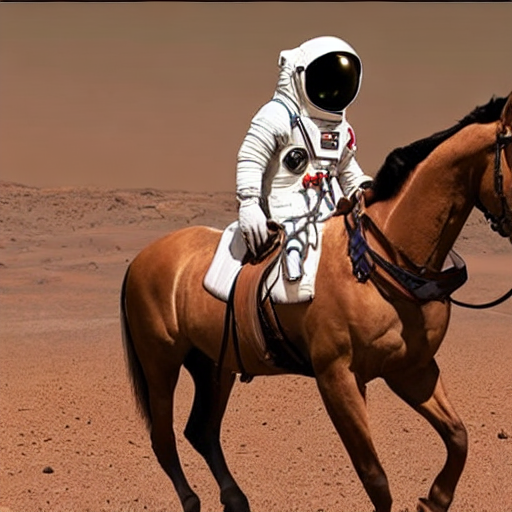

In [6]:
output = graph.run(
    prompt="A photo of an astronaut riding a horse on mars",
    negative_prompt="blurry",
    num_inference_steps=50,
    guidance_scale=7.5,
    num_images_per_prompt=1,
    seed=42,
    width=512,
    height=512,
)

output.images[0]

In [7]:
# import torch
# from diffusers import StableDiffusionPipeline

# pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16)

# pipe.to("cuda")

# output = pipe(
#     prompt="A photo of an astronaut riding a horse on mars",
#     negative_prompt="blurry",
#     num_inference_steps=50,
#     guidance_scale=7.5,
#     num_images_per_prompt=1,
#     generator=torch.Generator(device="cuda").manual_seed(42),
#     width=512,
#     height=512,
# )

# output.images[0]

### Добавление новых компонент в граф

In [8]:
from yggdrasill import Hypergraph, DiffusionGraphBuilder

graph = Hypergraph.from_template("sd15_text2image", device="cuda")

builder = DiffusionGraphBuilder(graph)
builder.add_component("CannyControlNet", "sd15.controlnet", pretrained="lllyasviel/sd-controlnet-canny")
builder.add_component("DepthControlNet", "sd15.controlnet", pretrained="lllyasviel/sd-controlnet-depth")
builder.add_component("IPAdapter", "sd15.ipadapter", pretrained="h94/IP-Adapter")
builder.to("cuda")

graph = builder.graph

[yggdrasill] Loading components from runwayml/stable-diffusion-v1-5: tokenizer, text_encoder, unet, vae, scheduler
[yggdrasill] Component cache hit: CLIPTokenizer from runwayml/stable-diffusion-v1-5/tokenizer
[yggdrasill] Component cache hit: CLIPTextModel from runwayml/stable-diffusion-v1-5/text_encoder
[yggdrasill] Component cache hit: UNet2DConditionModel from runwayml/stable-diffusion-v1-5/unet
[yggdrasill] Component cache hit: AutoencoderKL from runwayml/stable-diffusion-v1-5/vae
[yggdrasill] Component cache hit: Scheduler from runwayml/stable-diffusion-v1-5/scheduler
[yggdrasill] Loaded 5/5 components: tokenizer, text_encoder, unet, vae, scheduler
[yggdrasill] Loading components from lllyasviel/sd-controlnet-canny: controlnet
[yggdrasill] Loading ControlNetModel from lllyasviel/sd-controlnet-canny ...
An error occurred while trying to fetch lllyasviel/sd-controlnet-canny: lllyasviel/sd-controlnet-canny does not appear to have a file named diffusion_pytorch_model.fp16.safetensors.

Generating:   0%|          | 0/31 [00:00<?, ?step/s]

Generating: 100%|██████████| 31/31 [00:04<00:00,  6.33step/s]


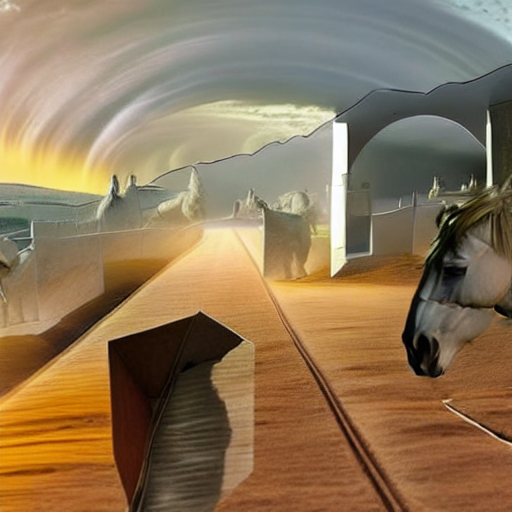

In [10]:
output = graph.run(
    prompt="A photo of an astronaut riding a horse on mars",
    negative_prompt="blurry",
    controlnet_image={
        "CannyControlNet": "https://media.licdn.com/dms/image/v2/C5112AQExoUiRNUfNyg/article-cover_image-shrink_720_1280/article-cover_image-shrink_720_1280/0/1582133550471?e=2147483647&v=beta&t=SAvSWpaMfcrgAB_tWPHZkrvFEGRXKSKo-fuiORZU16I",
        "DepthControlNet": "https://www.cyanilux.com/tutorials/depth/Preview.png",
    },
    controlnet_conditioning_scale={
        "CannyControlNet": 0.9,
        "DepthControlNet": 0.9,
    },
    ip_adapter_image={
        "IPAdapter": "https://res.cloudinary.com/jerrick/image/upload/d_642250b563292b35f27461a7.png,f_jpg,fl_progressive,q_auto,w_1024/63dfe49d72df38001c5175bc.jpg",
    },
    ip_adapter_conditioning_scale={
        "IPAdapter": 0.75,
    },
    num_inference_steps=30,
    guidance_scale=7.5,
    num_images_per_prompt=1,
    seed=42,
    width=512,
    height=512,
)

output.images[0]

### Замена компонентов в графе

In [11]:
from yggdrasill import Hypergraph, DiffusionGraphBuilder

graph = Hypergraph.from_template("sd15_text2image", device="cuda")

builder = DiffusionGraphBuilder(graph)
builder.replace_component("Backbone", "sd15.unet", pretrained="Lykon/DreamShaper")

[yggdrasill] Loading components from runwayml/stable-diffusion-v1-5: tokenizer, text_encoder, unet, vae, scheduler
[yggdrasill] Component cache hit: CLIPTokenizer from runwayml/stable-diffusion-v1-5/tokenizer
[yggdrasill] Component cache hit: CLIPTextModel from runwayml/stable-diffusion-v1-5/text_encoder
[yggdrasill] Component cache hit: UNet2DConditionModel from runwayml/stable-diffusion-v1-5/unet
[yggdrasill] Component cache hit: AutoencoderKL from runwayml/stable-diffusion-v1-5/vae
[yggdrasill] Component cache hit: Scheduler from runwayml/stable-diffusion-v1-5/scheduler
[yggdrasill] Loaded 5/5 components: tokenizer, text_encoder, unet, vae, scheduler
[yggdrasill] Loading components from Lykon/DreamShaper: unet
[yggdrasill] Loading UNet2DConditionModel from Lykon/DreamShaper/unet ...
An error occurred while trying to fetch Lykon/DreamShaper: Lykon/DreamShaper does not appear to have a file named diffusion_pytorch_model.safetensors.
[yggdrasill] Trying variant=fp16 for Lykon/DreamShap

Generating: 100%|██████████| 51/51 [00:06<00:00,  8.46step/s]


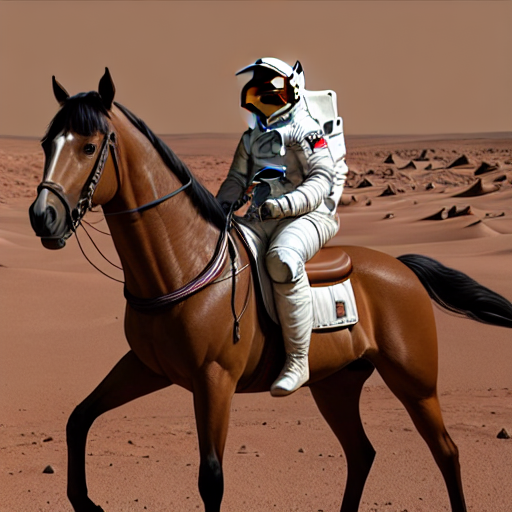

In [12]:
output = builder.run(
    prompt="A photo of an astronaut riding a horse on mars",
    negative_prompt="blurry",
    num_inference_steps=50,
    guidance_scale=7.5,
    num_images_per_prompt=1,
    seed=42,
    width=512,
    height=512,
)

output.images[0]

Generating: 100%|██████████| 50/50 [00:05<00:00,  8.68step/s]


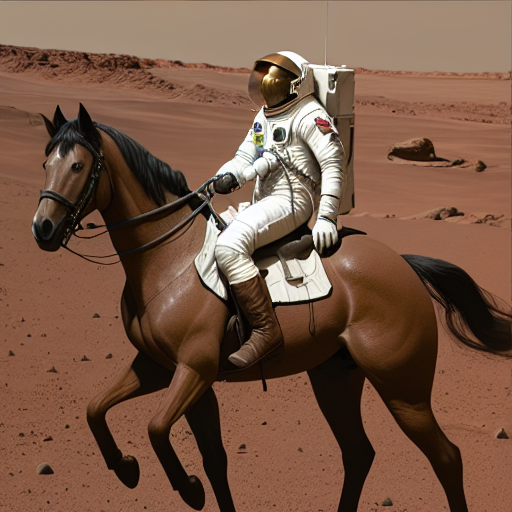

In [13]:
builder.replace_component("Scheduler", "sd15.scheduler", scheduler_type="euler")

output = builder.run(
    prompt="A photo of an astronaut riding a horse on mars",
    negative_prompt="blurry",
    num_inference_steps=50,
    guidance_scale=7.5,
    num_images_per_prompt=1,
    seed=42,
    width=512,
    height=512,
)

output.images[0]

[yggdrasill] Loading components from lllyasviel/sd-controlnet-canny: controlnet
[yggdrasill] Component cache hit: ControlNetModel from lllyasviel/sd-controlnet-canny/.
[yggdrasill] Loaded 1/1 components: controlnet
Generating: 100%|██████████| 50/50 [00:12<00:00,  3.98step/s]


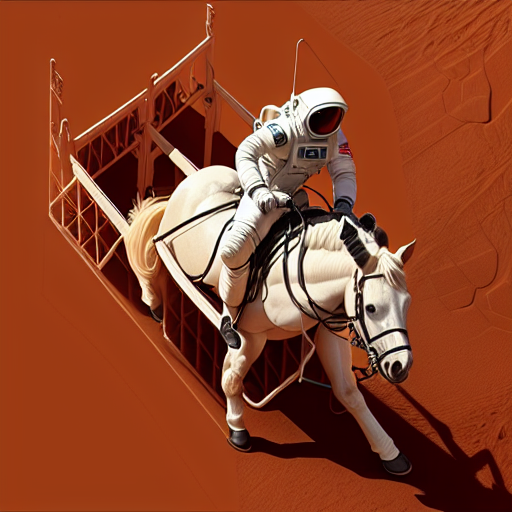

In [14]:
builder.add_component("ControlNet", "sd15.controlnet", pretrained="lllyasviel/sd-controlnet-canny")

output = builder.run(
    prompt="A photo of an astronaut riding a horse on mars",
    negative_prompt="blurry",
    controlnet_image={
        "ControlNet": "https://psv4.userapi.com/s/v1/d2/m_5kQALU9DlVvJ0xyyPHbhaaMFjJUlp_ovyz7p6vgPjeXd7yoTQ_VhG9a8YhQSXRw4KpwQD4sz_xoW79yuCvadoM8bbBMVD_8DWKhuLNjziAZbHOP--nd4ojZ9HokQ9527NWeCC8BIqI/1774007112940.jpg",
    },
    controlnet_conditioning_scale={
        "ControlNet": 0.5,
    },
    num_inference_steps=50,
    guidance_scale=7.5,
    num_images_per_prompt=1,
    seed=42,
    width=512,
    height=512,
)

output.images[0]

[yggdrasill] Component cache hit: CLIPVisionModelWithProjection from h94/IP-Adapter/models/image_encoder
[yggdrasill] Component cache hit: CLIPImageProcessor from openai/clip-vit-large-patch14/.
[yggdrasill] Loaded 2/2 components: image_encoder, feature_extractor
Generating: 100%|██████████| 50/50 [00:06<00:00,  7.41step/s]


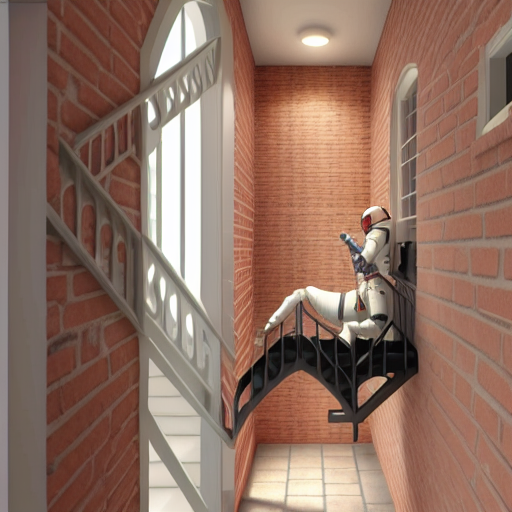

In [15]:
builder.add_component("IPAdapter", "sd15.ipadapter", pretrained="h94/IP-Adapter")

output = builder.run(
    prompt="A photo of an astronaut riding a horse on mars",
    negative_prompt="blurry",
    controlnet_image={
        "ControlNet": "https://psv4.userapi.com/s/v1/d2/m_5kQALU9DlVvJ0xyyPHbhaaMFjJUlp_ovyz7p6vgPjeXd7yoTQ_VhG9a8YhQSXRw4KpwQD4sz_xoW79yuCvadoM8bbBMVD_8DWKhuLNjziAZbHOP--nd4ojZ9HokQ9527NWeCC8BIqI/1774007112940.jpg",
    },
    controlnet_conditioning_scale={
        "ControlNet": 0.5,
    },
    ip_adapter_image={
        "IPAdapter": "https://images.stroistyle.com/posts/9467675-veranda-iz-kirpicha-2.jpg",
    },
    ip_adapter_conditioning_scale={
        "IPAdapter": 0.75,
    },
    num_inference_steps=50,
    guidance_scale=7.5,
    num_images_per_prompt=1,
    seed=42,
    width=512,
    height=512,
)

output.images[0]

[yggdrasill] Loading components from lllyasviel/sd-controlnet-scribble: controlnet
[yggdrasill] Component cache hit: ControlNetModel from lllyasviel/sd-controlnet-scribble/.
[yggdrasill] Loaded 1/1 components: controlnet
Generating: 100%|██████████| 50/50 [00:07<00:00,  6.99step/s]


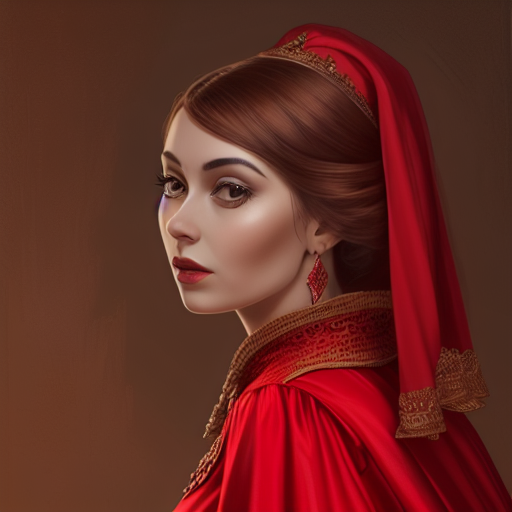

In [17]:
builder.add_component("ControlNetScribble", "sd15.controlnet", pretrained="lllyasviel/sd-controlnet-scribble")

output = builder.run(
    prompt="A woman with a red dress",
    negative_prompt="blurry",
    controlnet_image={
        "ControlNetScribble": "https://huggingface.co/takuma104/controlnet_dev/resolve/main/gen_compare/control_images/converted/control_vermeer_scribble.png",
    },
    controlnet_conditioning_scale={
        "ControlNetScribble": 0.9,
    },
    # ip_adapter_image={
    #     "IPAdapter": "https://images.stroistyle.com/posts/9467675-veranda-iz-kirpicha-2.jpg",
    # },
    # ip_adapter_conditioning_scale={
    #     "IPAdapter": 0.75,
    # },
    num_inference_steps=50,
    guidance_scale=7.5,
    num_images_per_prompt=1,
    seed=42,
    width=512,
    height=512,
)

output.images[0]

### Проверка работы img2img

[yggdrasill] Loading components from runwayml/stable-diffusion-v1-5: tokenizer, text_encoder, unet, vae, scheduler
[yggdrasill] Component cache hit: CLIPTokenizer from runwayml/stable-diffusion-v1-5/tokenizer
[yggdrasill] Component cache hit: CLIPTextModel from runwayml/stable-diffusion-v1-5/text_encoder
[yggdrasill] Component cache hit: UNet2DConditionModel from runwayml/stable-diffusion-v1-5/unet
[yggdrasill] Component cache hit: AutoencoderKL from runwayml/stable-diffusion-v1-5/vae
[yggdrasill] Component cache hit: Scheduler from runwayml/stable-diffusion-v1-5/scheduler
[yggdrasill] Loaded 5/5 components: tokenizer, text_encoder, unet, vae, scheduler
[yggdrasill] Loading components from Lykon/DreamShaper: unet
[yggdrasill] Component cache hit: UNet2DConditionModel from Lykon/DreamShaper/unet
[yggdrasill] Loaded 1/1 components: unet
Generating: 100%|██████████| 45/45 [00:05<00:00,  8.29step/s]


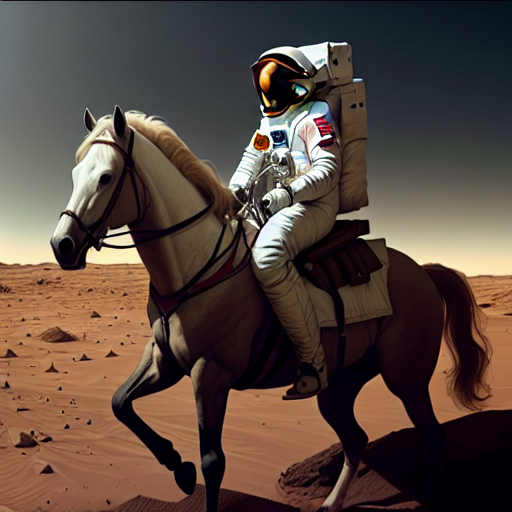

In [18]:
from yggdrasill import Hypergraph, DiffusionGraphBuilder

graph = Hypergraph.from_template("sd15_img2img", device="cuda")
builder = DiffusionGraphBuilder(graph)
builder.replace_component("Backbone", "sd15.unet", pretrained="Lykon/DreamShaper")
graph = builder.graph

output = graph.run(
    prompt="A photo of an astronaut riding a horse on mars",
    negative_prompt="blurry",
    image="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRtxLSt4-D6-Tps1EIHblCehsP0yB5evpwylw&s",
    strength=0.9,
    num_inference_steps=50,
    guidance_scale=7.5,
    num_images_per_prompt=1,
    seed=42,
    width=512,
    height=512,
)

output.images[0]

### Проверка работы inpaint

[yggdrasill] Loading components from runwayml/stable-diffusion-inpainting: tokenizer, text_encoder, unet, vae, scheduler
[yggdrasill] Component cache hit: CLIPTokenizer from runwayml/stable-diffusion-inpainting/tokenizer
[yggdrasill] Component cache hit: CLIPTextModel from runwayml/stable-diffusion-inpainting/text_encoder
[yggdrasill] Component cache hit: UNet2DConditionModel from runwayml/stable-diffusion-inpainting/unet
[yggdrasill] Component cache hit: AutoencoderKL from runwayml/stable-diffusion-inpainting/vae
[yggdrasill] Component cache hit: Scheduler from runwayml/stable-diffusion-inpainting/scheduler
[yggdrasill] Loaded 5/5 components: tokenizer, text_encoder, unet, vae, scheduler
Generating: 100%|██████████| 50/50 [00:02<00:00, 20.77step/s]


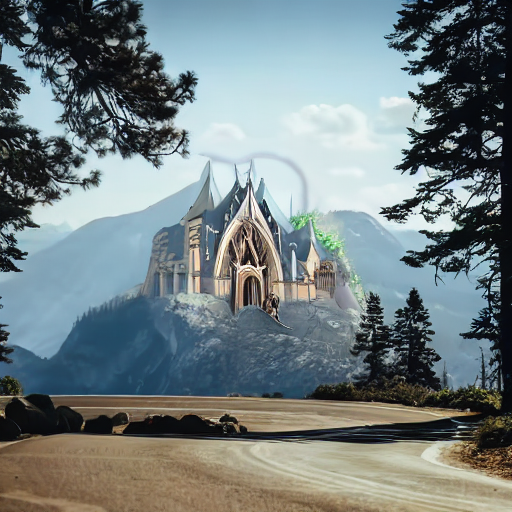

In [21]:
from yggdrasill import Hypergraph, DiffusionGraphBuilder

graph = Hypergraph.from_template("sd15_inpaint", device="cuda")

# builder = DiffusionGraphBuilder(graph)
# builder.replace_component("Backbone", "sd15.unet", pretrained="Lykon/DreamShaper")
# graph = builder.graph

output = graph.run(
    prompt="concept art digital painting of an elven castle, inspired by lord of the rings, highly detailed, 8k",
    negative_prompt="blurry",
    image="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/inpaint.png",
    mask_image="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/inpaint_mask.png",
    strength=1.0,
    num_inference_steps=50,
    guidance_scale=7.5,
    num_images_per_prompt=1,
    seed=42,
    width=512,
    height=512,
)

output.images[0]

### Проверка работы универсального графа

In [22]:
from yggdrasill import DiffusionGraphBuilder

builder = DiffusionGraphBuilder(name="MySD15Graph")
builder.add_component("Backbone", "sd15.unet", pretrained="Lykon/DreamShaper")
builder.add_component("Scheduler", "sd15.scheduler", pretrained="Lykon/DreamShaper")
builder.add_component("Tokenizer", "sd15.tokenizer", pretrained="Lykon/DreamShaper")
builder.add_component("TextEncoder", "sd15.text_encoder", pretrained="Lykon/DreamShaper")
builder.add_component("Autoencoder", "sd15.vae", pretrained="Lykon/DreamShaper")
builder.to("cuda")

[yggdrasill] Loading components from Lykon/DreamShaper: unet
[yggdrasill] Component cache hit: UNet2DConditionModel from Lykon/DreamShaper/unet
[yggdrasill] Loaded 1/1 components: unet
[yggdrasill] Loading components from Lykon/DreamShaper: scheduler
[yggdrasill] Loading Scheduler from Lykon/DreamShaper/scheduler ...
[yggdrasill] Loaded Scheduler from Lykon/DreamShaper/scheduler
[yggdrasill] Loaded 1/1 components: scheduler
[yggdrasill] Loading components from Lykon/DreamShaper: tokenizer
[yggdrasill] Loading CLIPTokenizer from Lykon/DreamShaper/tokenizer ...
[yggdrasill] Loaded CLIPTokenizer from Lykon/DreamShaper/tokenizer
[yggdrasill] Loaded 1/1 components: tokenizer
[yggdrasill] Loading components from Lykon/DreamShaper: text_encoder
[yggdrasill] Loading CLIPTextModel from Lykon/DreamShaper/text_encoder ...
[yggdrasill] Loading .bin from Lykon/DreamShaper/text_encoder (download may take a while) ...
[yggdrasill] Loaded CLIPTextModel from Lykon/DreamShaper/text_encoder
[yggdrasill] 

Generating: 100%|██████████| 45/45 [00:05<00:00,  8.19step/s]


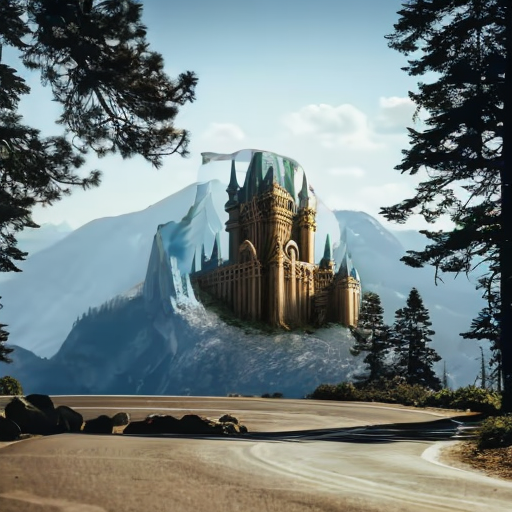

In [25]:
output = builder.run(
    prompt="concept art digital painting of an elven castle, inspired by lord of the rings, highly detailed, 8k",
    negative_prompt="blurry",
    image="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/inpaint.png",
    mask_image="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/inpaint_mask.png",
    strength=0.9,
    num_inference_steps=50,
    guidance_scale=7.5,
    num_images_per_prompt=1,
    seed=42,
    width=512,
    height=512,
)

output.images[0]

### Проверка что отдельные пайплайны выполняют только свою задачу 

[yggdrasill] Loading components from runwayml/stable-diffusion-v1-5: tokenizer, text_encoder, unet, vae, scheduler
[yggdrasill] Component cache hit: CLIPTokenizer from runwayml/stable-diffusion-v1-5/tokenizer
[yggdrasill] Component cache hit: CLIPTextModel from runwayml/stable-diffusion-v1-5/text_encoder
[yggdrasill] Component cache hit: UNet2DConditionModel from runwayml/stable-diffusion-v1-5/unet
[yggdrasill] Component cache hit: AutoencoderKL from runwayml/stable-diffusion-v1-5/vae
[yggdrasill] Component cache hit: Scheduler from runwayml/stable-diffusion-v1-5/scheduler
[yggdrasill] Loaded 5/5 components: tokenizer, text_encoder, unet, vae, scheduler
Generating: 100%|██████████| 51/51 [00:02<00:00, 21.14step/s]


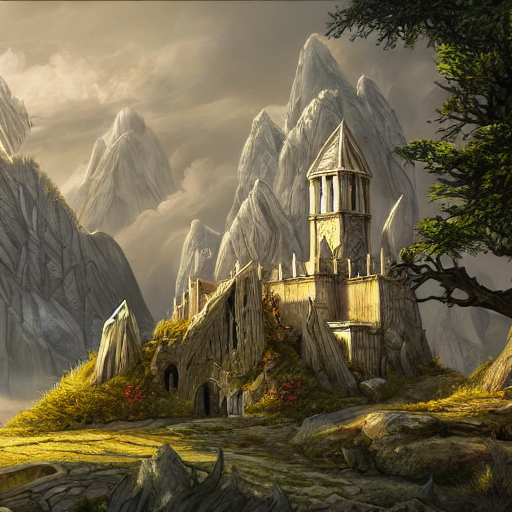

In [3]:
from yggdrasill import Hypergraph

graph = Hypergraph.from_template("sd15_text2image", device="cuda")

output = graph.run(
    prompt="concept art digital painting of an elven castle, inspired by lord of the rings, highly detailed, 8k",
    negative_prompt="blurry",
    image="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/inpaint.png",
    mask_image="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/inpaint_mask.png",
    strength=0.2,
    num_inference_steps=50,
    guidance_scale=7.5,
    num_images_per_prompt=1,
    seed=42,
    width=512,
    height=512,
)

output.images[0]

[yggdrasill] Loading components from runwayml/stable-diffusion-v1-5: tokenizer, text_encoder, unet, vae, scheduler
[yggdrasill] Component cache hit: CLIPTokenizer from runwayml/stable-diffusion-v1-5/tokenizer
[yggdrasill] Component cache hit: CLIPTextModel from runwayml/stable-diffusion-v1-5/text_encoder
[yggdrasill] Component cache hit: UNet2DConditionModel from runwayml/stable-diffusion-v1-5/unet
[yggdrasill] Component cache hit: AutoencoderKL from runwayml/stable-diffusion-v1-5/vae
[yggdrasill] Component cache hit: Scheduler from runwayml/stable-diffusion-v1-5/scheduler
[yggdrasill] Loaded 5/5 components: tokenizer, text_encoder, unet, vae, scheduler
Generating: 100%|██████████| 35/35 [00:01<00:00, 19.95step/s]


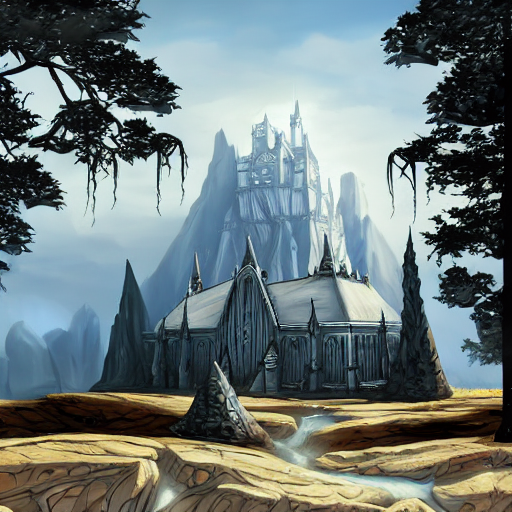

In [7]:
from yggdrasill import Hypergraph

graph = Hypergraph.from_template("sd15_img2img", device="cuda")

output = graph.run(
    prompt="concept art digital painting of an elven castle, inspired by lord of the rings, highly detailed, 8k",
    negative_prompt="blurry",
    image="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/inpaint.png",
    mask_image="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/inpaint_mask.png",
    strength=0.7,
    num_inference_steps=50,
    guidance_scale=7.5,
    num_images_per_prompt=1,
    seed=42,
    width=512,
    height=512,
)

output.images[0]

[yggdrasill] Loading components from runwayml/stable-diffusion-inpainting: tokenizer, text_encoder, unet, vae, scheduler
[yggdrasill] Loading CLIPTokenizer from runwayml/stable-diffusion-inpainting/tokenizer ...
[yggdrasill] Loaded CLIPTokenizer from runwayml/stable-diffusion-inpainting/tokenizer
[yggdrasill] Loading CLIPTextModel from runwayml/stable-diffusion-inpainting/text_encoder ...
[yggdrasill] Loaded CLIPTextModel from runwayml/stable-diffusion-inpainting/text_encoder
[yggdrasill] Loading UNet2DConditionModel from runwayml/stable-diffusion-inpainting/unet ...
/workspace/YggDrasill/.venv/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
[yggdrasill] Loaded UNet2DConditionModel from runwayml/stable-diffusion-inpainting/unet
[yggdrasill] Loading AutoencoderKL from runwayml/stable-dif

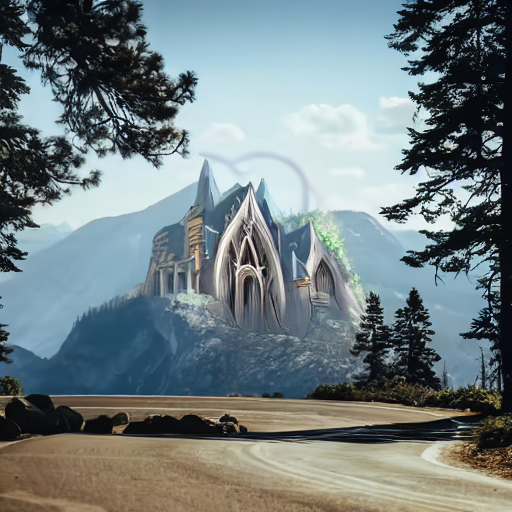

In [8]:
from yggdrasill import Hypergraph

graph = Hypergraph.from_template("sd15_inpaint", device="cuda")

output = graph.run(
    prompt="concept art digital painting of an elven castle, inspired by lord of the rings, highly detailed, 8k",
    negative_prompt="blurry",
    image="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/inpaint.png",
    mask_image="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/inpaint_mask.png",
    strength=0.9,
    num_inference_steps=50,
    guidance_scale=7.5,
    num_images_per_prompt=1,
    seed=42,
    width=512,
    height=512,
)

output.images[0]